# Resource Perspective — Drift Subtype Visualizations

This notebook is organized by **resource drift subtype**. It reads the drift metadata from
`drift_info`, groups all resource drifts by `subtype`, and then shows only the plots that are
most useful for that subtype.

- `reassignment` → activity-resource assignment shifts
- `workload_distribution` → event-count shifts across resources
- `service_time` → processing duration and wait-time shifts
- `pool_size` → active resource pool changes
- `handover` → resource-to-resource transition changes


## 0 · Setup and drift metadata


In [85]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

project_root = Path.cwd()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent

log_path = project_root / "data" / "resource" / "resource_001.xes"
WINDOW_DAYS = 30


def read_drift_info(xes_path):
    """Read the log-level drift_info JSON attribute without loading the full log."""
    ns = "{http://www.xes-standard.org/}"
    for event, elem in ET.iterparse(str(xes_path), events=("start", "end")):
        if event == "end" and elem.tag == f"{ns}string" and elem.attrib.get("key") == "drift_info":
            return json.loads(elem.attrib["value"])
        if event == "start" and elem.tag == f"{ns}trace":
            break
    return []


_drift_info = read_drift_info(log_path)
drift_df = pd.DataFrame(_drift_info)
if drift_df.empty:
    drift_df = pd.DataFrame(columns=[
        "drift_id", "perspective", "subtype", "drift_type",
        "change_point_timestamp", "timestamp", "change_details"
    ])
else:
    drift_df["timestamp"] = pd.to_datetime(drift_df["change_point_timestamp"], utc=True)
    drift_df = drift_df.sort_values("timestamp").reset_index(drop=True)

resource_drift_df = drift_df[drift_df["perspective"].eq("resource")].copy()
DRIFT_TIMESTAMPS = resource_drift_df["timestamp"].tolist()
DRIFT_LABELS = resource_drift_df["drift_id"].tolist()

print(f"log path: {log_path}")
print(f"resource drifts: {len(resource_drift_df)}")
resource_drift_df[["drift_id", "timestamp", "drift_type", "subtype", "change_details"]]


log path: /Users/bd/Projects/thesis/data/resource/resource_001.xes
resource drifts: 5


,drift_id,timestamp,drift_type,subtype,change_details
0,d01,2020-05-26 00:00:00+00:00,sudden,pool_size,"{'active_resources': ['res_001', 'res_002', 'r..."
1,d02,2020-05-26 00:00:00+00:00,sudden,workload_distribution,"{'affected_resources': ['res_001', 'res_002', ..."
2,d03,2020-05-26 00:00:00+00:00,sudden,reassignment,"{'activities': ['a', 'c'], 'reassignments': [{..."
3,d04,2020-05-26 00:00:00+00:00,sudden,service_time,{'multiplier_changes': {'res_001': {'new_multi...
4,d05,2020-05-26 00:00:00+00:00,sudden,handover,"{'new_dominant_target': 'res_005', 'old_domina..."


## 1 · Load and enrich the event log


In [86]:
df = pm4py.read_xes(str(log_path))
df = df.rename(
    columns={
        "case:concept:name": "case_id",
        "concept:name": "activity",
        "time:timestamp": "timestamp",
        "org:resource": "resource",
        "org:role": "role",
    }
)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["start_timestamp"] = pd.to_datetime(df.get("start_timestamp"), utc=True, errors="coerce")
df = df.sort_values(["case_id", "timestamp"]).reset_index(drop=True)
df["week"] = df["timestamp"].dt.to_period("W").dt.start_time

if "event:duration_min" not in df.columns:
    df["event:duration_min"] = (
        df["timestamp"] - df["start_timestamp"]
    ).dt.total_seconds().div(60).clip(lower=0)

# Wait time = gap from previous event end to this event start within the same case.
df["prev_end"] = df.groupby("case_id")["timestamp"].shift(1)
df["wait_min"] = ((df["start_timestamp"] - df["prev_end"]).dt.total_seconds() / 60).clip(lower=0)

# Handover events between consecutive resources inside a case.
df["prev_resource"] = df.groupby("case_id")["resource"].shift(1)
handovers = df.dropna(subset=["prev_resource"]).query("prev_resource != resource").copy()

resources_sorted = sorted(df["resource"].dropna().unique())
roles_sorted = sorted(df["role"].dropna().unique())
activities_sorted = sorted(df["activity"].dropna().unique())

RESOURCE_COLORS = {
    r: to_hex(c)
    for r, c in zip(resources_sorted, sns.color_palette("tab20", n_colors=len(resources_sorted)))
}
ROLE_COLORS = {
    r: to_hex(c)
    for r, c in zip(roles_sorted, sns.color_palette("Set2", n_colors=len(roles_sorted)))
}

print(f"events:     {len(df):,}")
print(f"cases:      {df['case_id'].nunique():,}")
print(f"resources:  {df['resource'].nunique():,}")
print(f"activities: {df['activity'].nunique():,}")
print(f"roles:      {df['role'].nunique():,}")
print(f"time span:  {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head()


parsing log, completed traces :: 100%|██████████| 4000/4000 [00:00<00:00, 11583.00it/s]
/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_48151/2764001553.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["timestamp"].dt.to_period("W").dt.start_time


events:     24,000
cases:      4,000
resources:  8
activities: 6
roles:      2
time span:  2020-01-01 02:25:31.188048+00:00 → 2020-10-18 12:35:09.733446+00:00


,event:id,activity,start_timestamp,timestamp,event:duration_min,resource,role,case_id,case:case_type,case:amount,case:region,week,prev_end,wait_min,prev_resource
0,evt_00000001,a,2020-01-01 02:02:48.276939+00:00,2020-01-01 02:25:31.188048+00:00,22.715185,res_001,role_01,case_000001,type_02,1363.27,DE-BW,2019-12-30,NaT,NaN,NaN
1,evt_00000002,c,2020-01-01 02:27:17.178035+00:00,2020-01-01 02:41:44.018941+00:00,14.447348,res_008,role_02,case_000001,type_02,1363.27,DE-BW,2019-12-30,2020-01-01 02:25:31.188048+00:00,1.766500,res_001
2,evt_00000003,e,2020-01-01 02:45:04.703700+00:00,2020-01-01 02:59:29.640678+00:00,14.415616,res_008,role_02,case_000001,type_02,1363.27,DE-BW,2019-12-30,2020-01-01 02:41:44.018941+00:00,3.344746,res_008
3,evt_00000004,b,2020-01-01 03:00:23.463137+00:00,2020-01-01 03:14:03.593330+00:00,13.668837,res_004,role_02,case_000001,type_02,1363.27,DE-BW,2019-12-30,2020-01-01 02:59:29.640678+00:00,0.897041,res_008
4,evt_00000005,d,2020-01-01 03:14:48.562377+00:00,2020-01-01 03:29:52.851937+00:00,15.071493,res_005,role_01,case_000001,type_02,1363.27,DE-BW,2019-12-30,2020-01-01 03:14:03.593330+00:00,0.749484,res_004


## 2 · Shared plotting helpers


In [87]:
def drifts_for(subtype):
    """Return resource drifts of a given subtype as dictionaries."""
    if resource_drift_df.empty:
        return []
    return resource_drift_df[resource_drift_df["subtype"].eq(subtype)].to_dict("records")


def subtype_header(subtype, description):
    rows = drifts_for(subtype)
    print(f"{subtype}: {len(rows)} drift(s)")
    print(description)
    if rows:
        return pd.DataFrame(rows)[["drift_id", "timestamp", "drift_type", "change_details"]]
    print("No drift of this subtype is present in the loaded log.")
    return None


def drift_title(drift):
    return f"{drift['drift_id']} · {drift['drift_type']} · {drift['subtype']} @ {drift['timestamp']}"


def draw_drift_lines(ax, drifts=None, *, color="black", label_color="black"):
    rows = resource_drift_df.to_dict("records") if drifts is None else drifts
    if not rows:
        return
    ymin, ymax = ax.get_ylim()
    for drift in rows:
        ts = drift["timestamp"]
        label = f"{drift['drift_id']}\n{drift['subtype']}"
        ax.axvline(ts, color=color, linestyle="--", linewidth=1.0, alpha=0.8)
        ax.text(ts, ymax, label, ha="center", va="bottom", fontsize=7, color=label_color,
                bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.15"))
    ax.set_ylim(ymin, ymax)


def pre_post_window(drift, window_days=WINDOW_DAYS):
    ts = drift["timestamp"]
    lo = ts - pd.Timedelta(days=window_days)
    hi = ts + pd.Timedelta(days=window_days)
    pre = df[(df["timestamp"] >= lo) & (df["timestamp"] < ts)]
    post = df[(df["timestamp"] >= ts) & (df["timestamp"] < hi)]
    print(drift_title(drift))
    print(f"pre:  [{lo}, {ts}) · {len(pre):,} events · {pre['case_id'].nunique():,} cases · {pre['resource'].nunique()} resources")
    print(f"post: [{ts}, {hi}) · {len(post):,} events · {post['case_id'].nunique():,} cases · {post['resource'].nunique()} resources")
    return pre, post


def plot_resource_bars(pre, post, value_fn, ylabel, title, *, resources=None):
    resources = resources or resources_sorted
    series = [value_fn(sub).reindex(resources, fill_value=0) for sub in (pre, post)]
    ymax = max((s.max(skipna=True) for s in series if len(s)), default=1) or 1
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, values, label in zip(axes, series, ["Pre", "Post"]):
        ax.bar(values.index, values.values, color=[RESOURCE_COLORS.get(r, "gray") for r in values.index])
        ax.set_title(label)
        ax.tick_params(axis="x", rotation=45)
        ax.set_xlabel("Resource")
    axes[0].set_ylabel(ylabel)
    axes[0].set_ylim(0, ymax * 1.1)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_resource_activity_heatmaps(pre, post, title, *, activities=None):
    activities = activities or activities_sorted
    pre_ct = pd.crosstab(pre["resource"], pre["activity"]).reindex(
        index=resources_sorted, columns=activities, fill_value=0
    )
    post_ct = pd.crosstab(post["resource"], post["activity"]).reindex(
        index=resources_sorted, columns=activities, fill_value=0
    )
    vmax = max(pre_ct.values.max(), post_ct.values.max()) or 1
    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, 0.45 * len(resources_sorted))), sharey=True)
    sns.heatmap(pre_ct, annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax, ax=axes[0], cbar=False)
    axes[0].set_title("Pre")
    sns.heatmap(post_ct, annot=True, fmt="d", cmap="rocket_r", vmin=0, vmax=vmax, ax=axes[1])
    axes[1].set_title("Post")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_metric_timeseries(metric, agg="mean", *, title, ylabel, drifts=None, highlight=None):
    weekly = (
        df.groupby(["week", "resource"])[metric].agg(agg)
        .unstack(fill_value=np.nan)
        .reindex(columns=resources_sorted)
        .sort_index()
    )
    fig, ax = plt.subplots(figsize=(14, 5))
    highlight = set(highlight or [])
    for resource in resources_sorted:
        if weekly[resource].notna().any():
            ax.plot(
                weekly.index,
                weekly[resource],
                label=resource,
                color=RESOURCE_COLORS[resource],
                linewidth=2.5 if resource in highlight else 1.3,
                alpha=1.0 if not highlight or resource in highlight else 0.35,
            )
    ax.set_title(title)
    ax.set_xlabel("Week")
    ax.set_ylabel(ylabel)
    ax.set_xlim(weekly.index.min(), weekly.index.max())
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, title="Resource")
    draw_drift_lines(ax, drifts=drifts, color="red", label_color="red")
    plt.tight_layout()
    plt.show()


def plot_weekly_resource_stack(drifts=None, title="Weekly events per resource"):
    weekly_resource = (
        df.groupby(["week", "resource"]).size()
        .unstack(fill_value=0)
        .reindex(columns=resources_sorted, fill_value=0)
        .sort_index()
    )
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.stackplot(
        weekly_resource.index,
        weekly_resource.T.values,
        labels=weekly_resource.columns,
        colors=[RESOURCE_COLORS[r] for r in weekly_resource.columns],
    )
    ax.set_title(title)
    ax.set_xlabel("Week")
    ax.set_ylabel("Events")
    ax.set_xlim(weekly_resource.index.min(), weekly_resource.index.max())
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, title="Resource")
    draw_drift_lines(ax, drifts=drifts)
    plt.tight_layout()
    plt.show()


def handover_matrix(sub):
    h = sub.dropna(subset=["prev_resource"]).query("prev_resource != resource")
    mat = pd.crosstab(h["prev_resource"], h["resource"]).reindex(
        index=resources_sorted, columns=resources_sorted, fill_value=0
    )
    return mat


def plot_handover_heatmaps(pre, post, title):
    pre_mat = handover_matrix(pre)
    post_mat = handover_matrix(post)
    vmax = max(pre_mat.values.max(), post_mat.values.max()) or 1
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    sns.heatmap(pre_mat, annot=True, fmt="d", cmap="mako", vmin=0, vmax=vmax, ax=axes[0], cbar=False)
    axes[0].set_title("Pre")
    sns.heatmap(post_mat, annot=True, fmt="d", cmap="mako", vmin=0, vmax=vmax, ax=axes[1])
    axes[1].set_title("Post")
    for ax in axes:
        ax.set_xlabel("To resource")
    axes[0].set_ylabel("From resource")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


## 3 · Overview — all resource drifts

This overview keeps all resource drift markers visible. The subtype-specific sections below narrow
that view to the features most directly affected by each subtype.


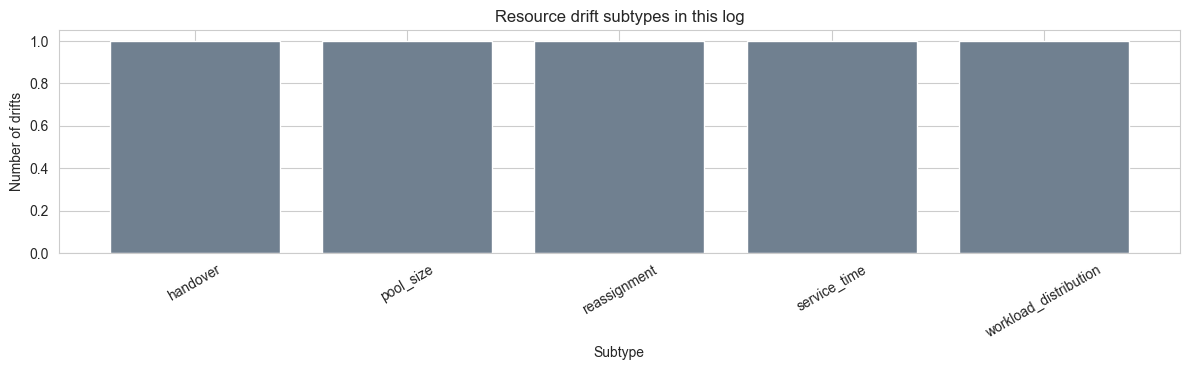

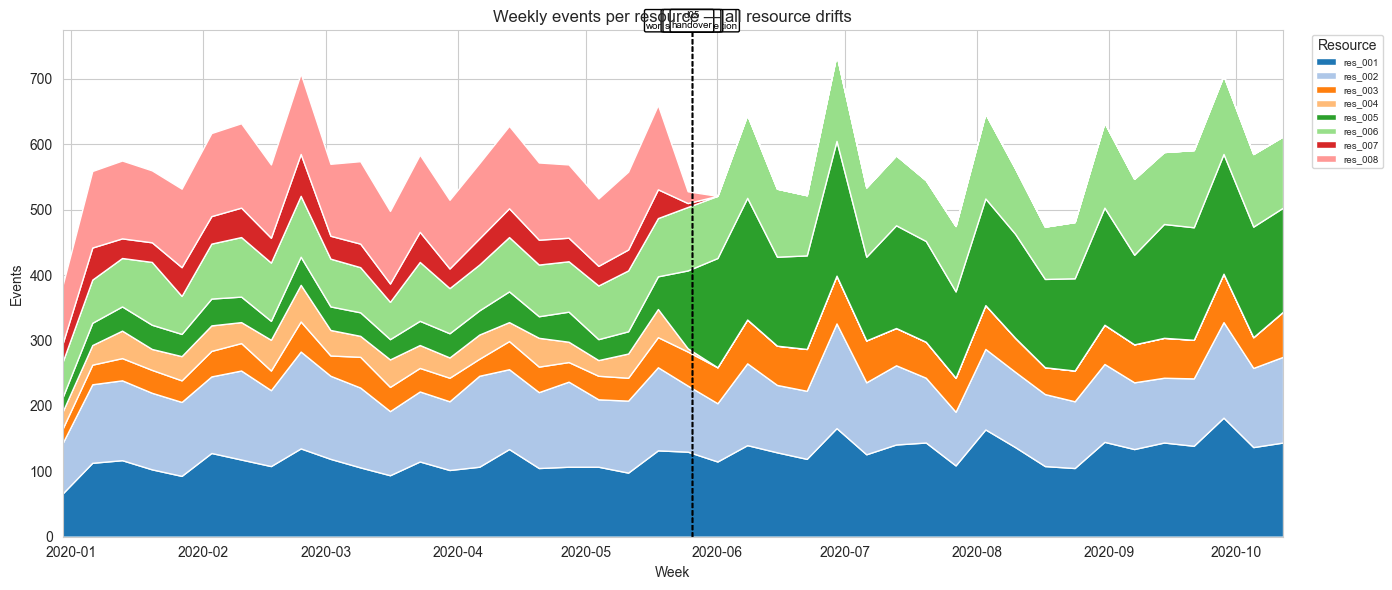

In [88]:
fig, ax = plt.subplots(figsize=(12, 3.8))
subtype_counts = resource_drift_df["subtype"].value_counts().sort_index() if not resource_drift_df.empty else pd.Series(dtype=int)
ax.bar(subtype_counts.index, subtype_counts.values, color="slategray")
ax.set_title("Resource drift subtypes in this log")
ax.set_xlabel("Subtype")
ax.set_ylabel("Number of drifts")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

plot_weekly_resource_stack(title="Weekly events per resource — all resource drifts")


## 4 · Subtype: `reassignment`

Visual target: **which resources perform each activity**. This section highlights activity-resource
shares and pre/post resource-activity count matrices for reassignment drifts.


reassignment: 1 drift(s)
Expected signal: activity-resource event counts and per-activity resource shares.

d03 · sudden · reassignment @ 2020-05-26 00:00:00+00:00
affected activities: ['a', 'c']


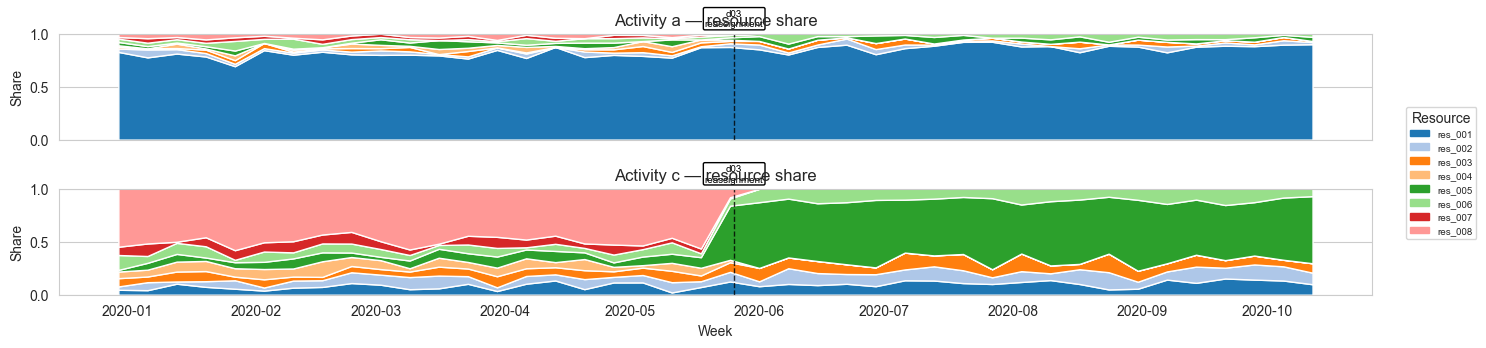

d03 · sudden · reassignment @ 2020-05-26 00:00:00+00:00
pre:  [2020-04-26 00:00:00+00:00, 2020-05-26 00:00:00+00:00) · 2,526 events · 421 cases · 8 resources
post: [2020-05-26 00:00:00+00:00, 2020-06-25 00:00:00+00:00) · 2,343 events · 392 cases · 5 resources


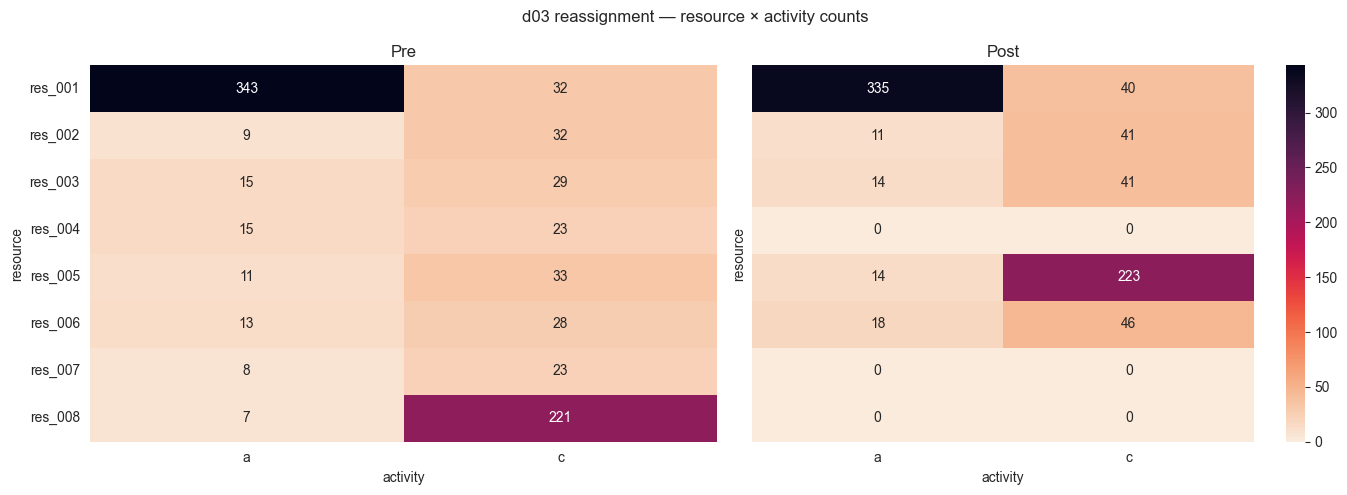

In [89]:
subtype_header(
    "reassignment",
    "Expected signal: activity-resource event counts and per-activity resource shares.",
)

for drift in drifts_for("reassignment"):
    details = drift.get("change_details") or {}
    if details.get("activities") == "all":
        affected_activities = activities_sorted
    else:
        affected_activities = [
            a for a in details.get("activities", [])
            if a in activities_sorted
        ]
    if not affected_activities and "reassignments" in details:
        affected_activities = sorted({r["activity"] for r in details["reassignments"] if r.get("activity") in activities_sorted})
    affected_activities = affected_activities or activities_sorted

    print("\n" + drift_title(drift))
    print("affected activities:", affected_activities)

    axes_count = len(affected_activities)
    fig, axes = plt.subplots(axes_count, 1, figsize=(14, max(3, 1.8 * axes_count)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, activity in zip(axes, affected_activities):
        sub = df[df["activity"].eq(activity)]
        weekly = (
            sub.groupby(["week", "resource"]).size()
            .unstack(fill_value=0)
            .reindex(columns=resources_sorted, fill_value=0)
            .sort_index()
        )
        share = weekly.div(weekly.sum(axis=1), axis=0).fillna(0)
        ax.stackplot(share.index, share.T.values, colors=[RESOURCE_COLORS[r] for r in share.columns])
        draw_drift_lines(ax, drifts=[drift])
        ax.set_title(f"Activity {activity} — resource share")
        ax.set_ylim(0, 1)
        ax.set_ylabel("Share")
    axes[-1].set_xlabel("Week")
    handles = [plt.Rectangle((0, 0), 1, 1, color=RESOURCE_COLORS[r]) for r in resources_sorted]
    fig.legend(handles, resources_sorted, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=7, title="Resource")
    plt.tight_layout()
    plt.show()

    pre, post = pre_post_window(drift)
    plot_resource_activity_heatmaps(
        pre,
        post,
        f"{drift['drift_id']} reassignment — resource × activity counts",
        activities=affected_activities,
    )


## 5 · Subtype: `workload_distribution`

Visual target: **event counts per resource**. This section focuses on workload concentration,
heavy resources, and resource-activity count changes.


workload_distribution: 1 drift(s)
Expected signal: events per resource, active cases per resource, and activity-resource event counts.

d02 · sudden · workload_distribution @ 2020-05-26 00:00:00+00:00
heavy / affected resources: ['res_002', 'res_006']
heavy resource share: 0.7


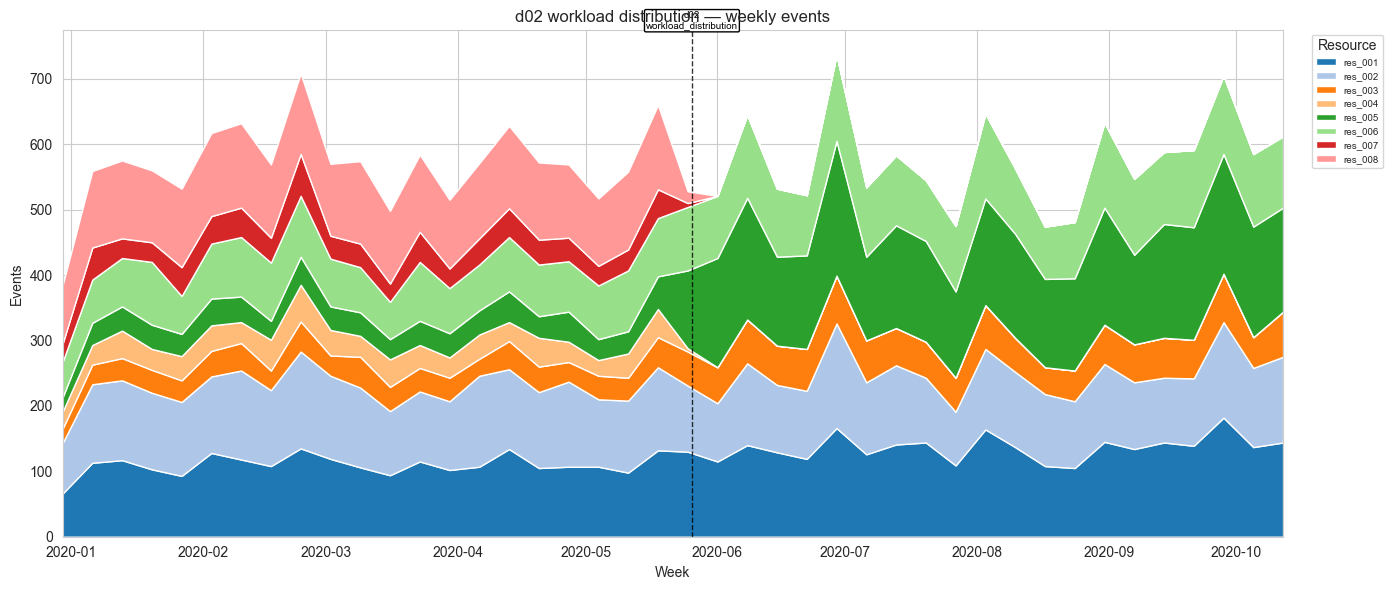

d02 · sudden · workload_distribution @ 2020-05-26 00:00:00+00:00
pre:  [2020-04-26 00:00:00+00:00, 2020-05-26 00:00:00+00:00) · 2,526 events · 421 cases · 8 resources
post: [2020-05-26 00:00:00+00:00, 2020-06-25 00:00:00+00:00) · 2,343 events · 392 cases · 5 resources


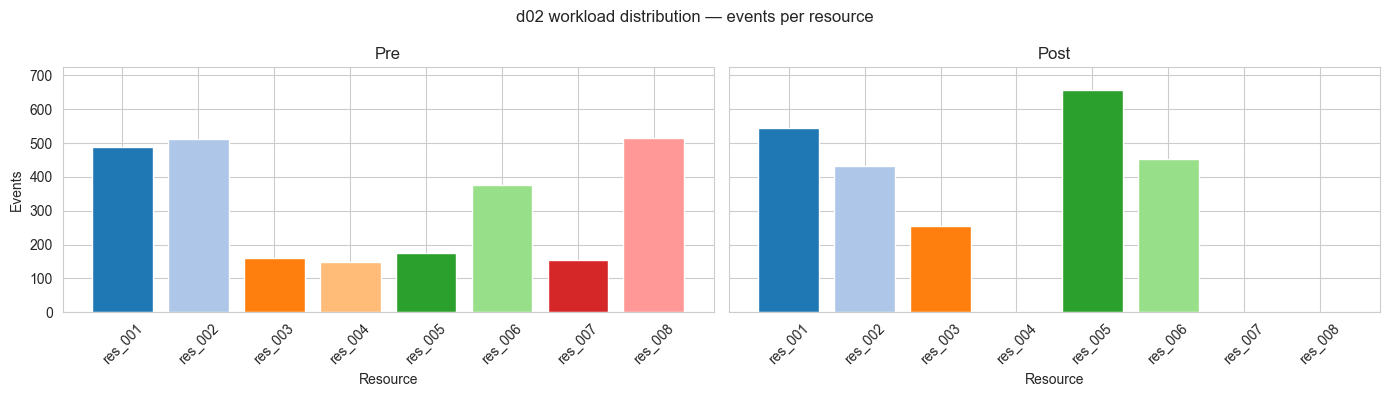

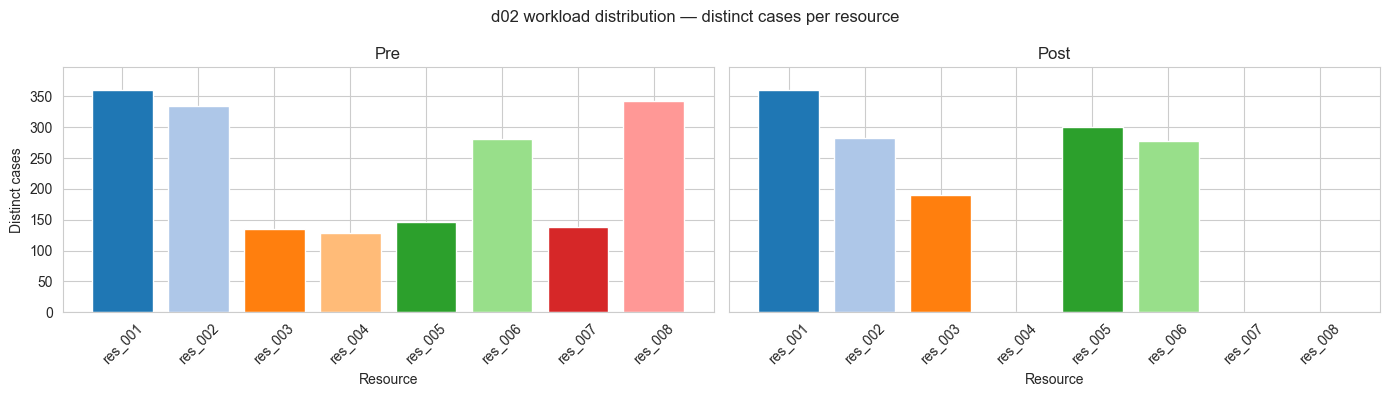

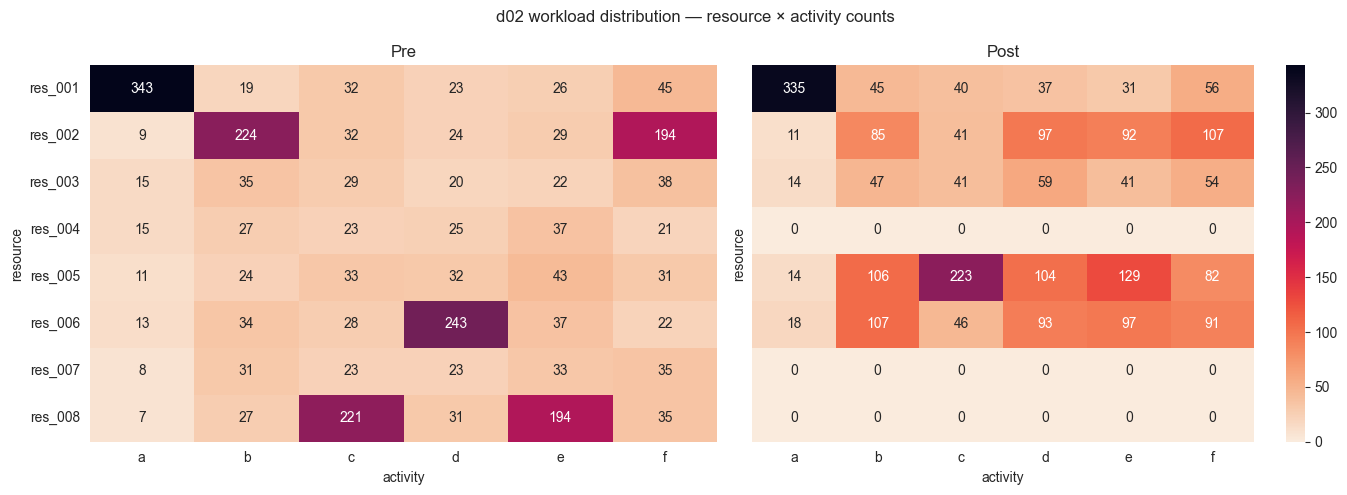

In [90]:
subtype_header(
    "workload_distribution",
    "Expected signal: events per resource, active cases per resource, and activity-resource event counts.",
)

for drift in drifts_for("workload_distribution"):
    details = drift.get("change_details") or {}
    heavy_resources = details.get("heavy_resources") or details.get("affected_resources") or []
    print("\n" + drift_title(drift))
    print("heavy / affected resources:", heavy_resources)
    print("heavy resource share:", details.get("heavy_resource_share", "n/a"))

    plot_weekly_resource_stack(drifts=[drift], title=f"{drift['drift_id']} workload distribution — weekly events")
    pre, post = pre_post_window(drift)
    plot_resource_bars(
        pre,
        post,
        lambda sub: sub["resource"].value_counts(),
        "Events",
        f"{drift['drift_id']} workload distribution — events per resource",
    )
    plot_resource_bars(
        pre,
        post,
        lambda sub: sub.groupby("resource")["case_id"].nunique(),
        "Distinct cases",
        f"{drift['drift_id']} workload distribution — distinct cases per resource",
    )
    plot_resource_activity_heatmaps(
        pre,
        post,
        f"{drift['drift_id']} workload distribution — resource × activity counts",
    )


## 6 · Subtype: `service_time`

Visual target: **event duration and wait time per resource**. The drift changes resource speed
multipliers, so duration and case timing are the most direct views.


service_time: 1 drift(s)
Expected signal: mean event duration per resource and mean wait into resource.

d04 · sudden · service_time @ 2020-05-26 00:00:00+00:00
affected resources: ['res_001', 'res_002', 'res_003', 'res_005', 'res_006']
multipliers: {'res_001': {'new_multiplier': 2.5873, 'old_multiplier': 1.0}, 'res_002': {'new_multiplier': 2.0272, 'old_multiplier': 1.0}, 'res_003': {'new_multiplier': 2.3028, 'old_multiplier': 1.0}, 'res_005': {'new_multiplier': 0.547, 'old_multiplier': 1.0}, 'res_006': {'new_multiplier': 1.7611, 'old_multiplier': 1.0}}


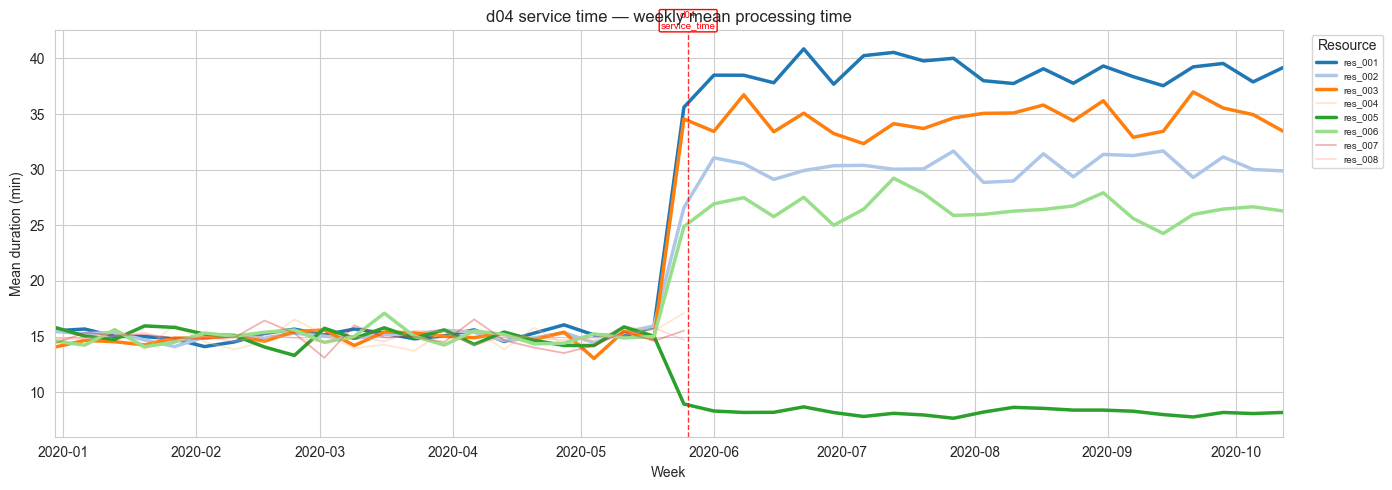

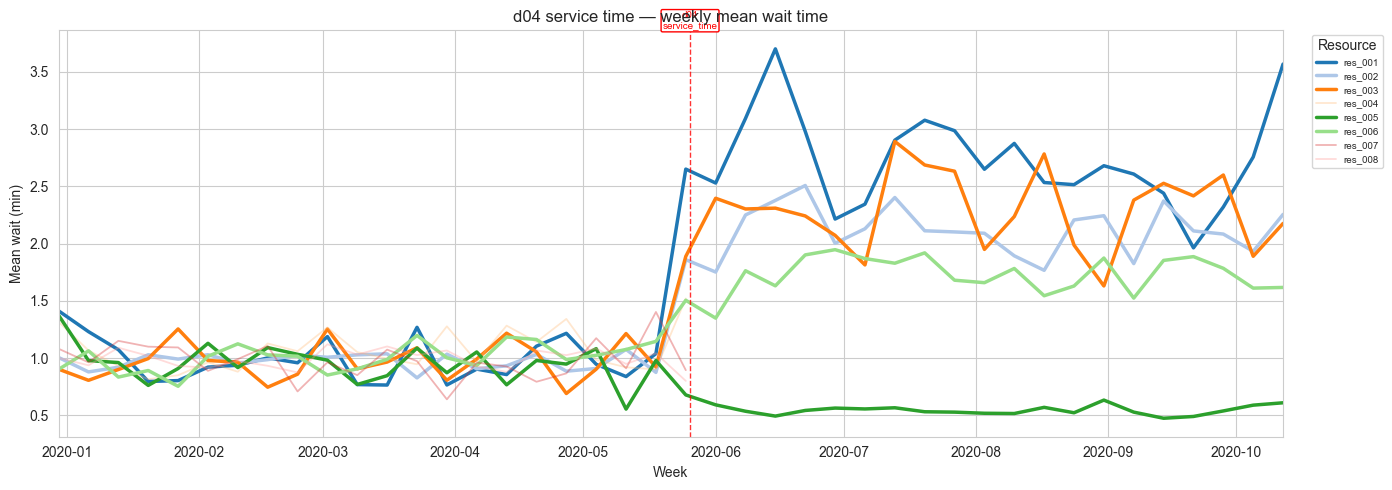

d04 · sudden · service_time @ 2020-05-26 00:00:00+00:00
pre:  [2020-04-26 00:00:00+00:00, 2020-05-26 00:00:00+00:00) · 2,526 events · 421 cases · 8 resources
post: [2020-05-26 00:00:00+00:00, 2020-06-25 00:00:00+00:00) · 2,343 events · 392 cases · 5 resources


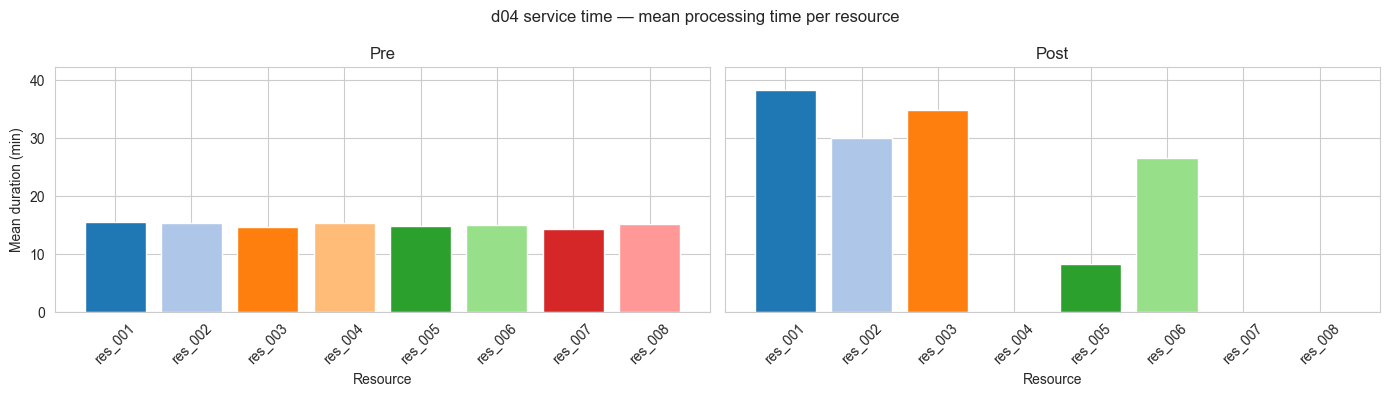

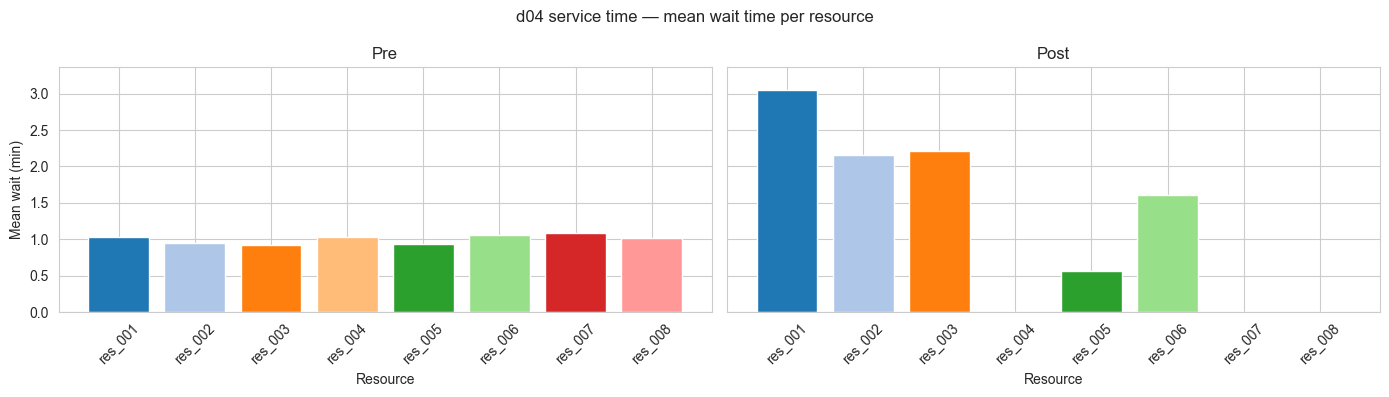

/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_48151/4270676498.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_48151/4270676498.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


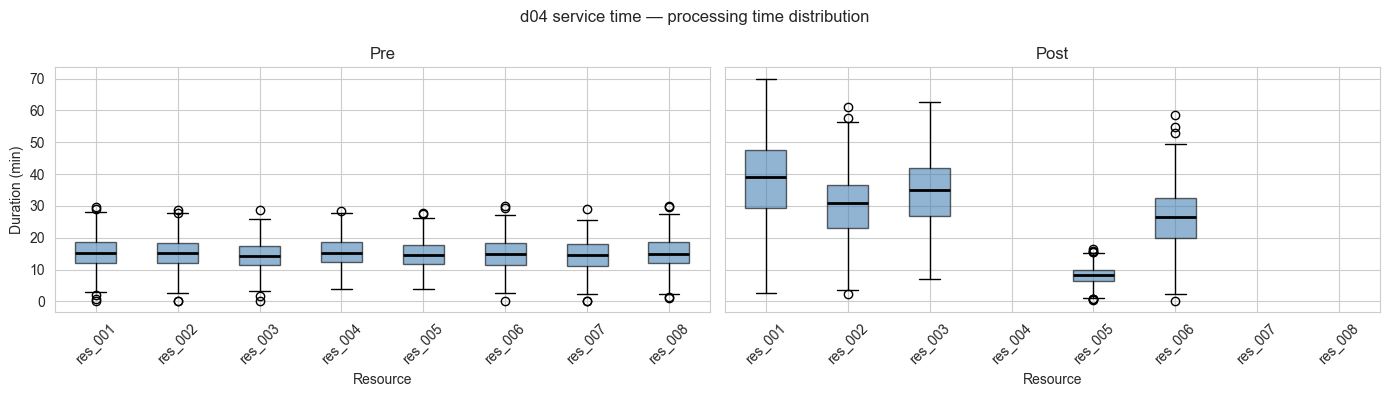

In [91]:
subtype_header(
    "service_time",
    "Expected signal: mean event duration per resource and mean wait into resource.",
)

for drift in drifts_for("service_time"):
    details = drift.get("change_details") or {}
    multiplier_changes = details.get("multiplier_changes", {})
    affected_resources = list(multiplier_changes) or details.get("resources", [])
    if affected_resources == "all":
        affected_resources = resources_sorted
    print("\n" + drift_title(drift))
    print("affected resources:", affected_resources)
    print("multipliers:", multiplier_changes)

    plot_metric_timeseries(
        "event:duration_min",
        title=f"{drift['drift_id']} service time — weekly mean processing time",
        ylabel="Mean duration (min)",
        drifts=[drift],
        highlight=affected_resources,
    )
    plot_metric_timeseries(
        "wait_min",
        title=f"{drift['drift_id']} service time — weekly mean wait time",
        ylabel="Mean wait (min)",
        drifts=[drift],
        highlight=affected_resources,
    )

    pre, post = pre_post_window(drift)
    plot_resource_bars(
        pre,
        post,
        lambda sub: sub.groupby("resource")["event:duration_min"].mean(),
        "Mean duration (min)",
        f"{drift['drift_id']} service time — mean processing time per resource",
    )
    plot_resource_bars(
        pre,
        post,
        lambda sub: sub.dropna(subset=["wait_min"]).groupby("resource")["wait_min"].mean(),
        "Mean wait (min)",
        f"{drift['drift_id']} service time — mean wait time per resource",
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, sub, label in zip(axes, [pre, post], ["Pre", "Post"]):
        data = [sub[sub["resource"].eq(r)]["event:duration_min"].dropna().values for r in resources_sorted]
        ax.boxplot(
            data,
            labels=resources_sorted,
            patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6),
            medianprops=dict(color="black", linewidth=2),
        )
        ax.set_title(label)
        ax.tick_params(axis="x", rotation=45)
        ax.set_xlabel("Resource")
    axes[0].set_ylabel("Duration (min)")
    fig.suptitle(f"{drift['drift_id']} service time — processing time distribution", fontsize=12)
    plt.tight_layout()
    plt.show()


## 7 · Subtype: `pool_size`

Visual target: **active resource set size**. This section shows how many resources are active over
time and which resources remain active before and after the drift.


pool_size: 1 drift(s)
Expected signal: distinct active resources, events per resource, and active cases per resource.

d01 · sudden · pool_size @ 2020-05-26 00:00:00+00:00
old pool size: 8 new pool size: 5
new active resources: ['res_001', 'res_002', 'res_003', 'res_005', 'res_006']


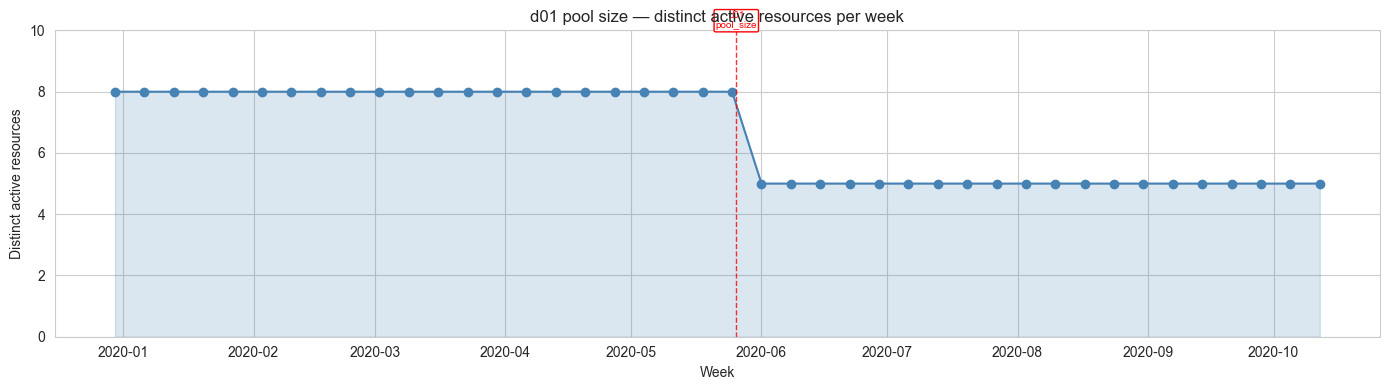

d01 · sudden · pool_size @ 2020-05-26 00:00:00+00:00
pre:  [2020-04-26 00:00:00+00:00, 2020-05-26 00:00:00+00:00) · 2,526 events · 421 cases · 8 resources
post: [2020-05-26 00:00:00+00:00, 2020-06-25 00:00:00+00:00) · 2,343 events · 392 cases · 5 resources


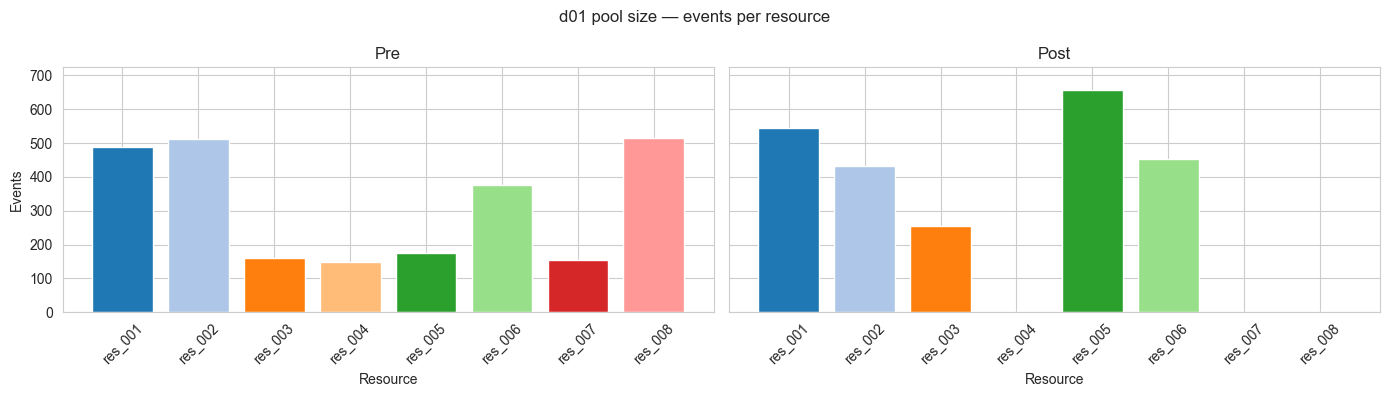

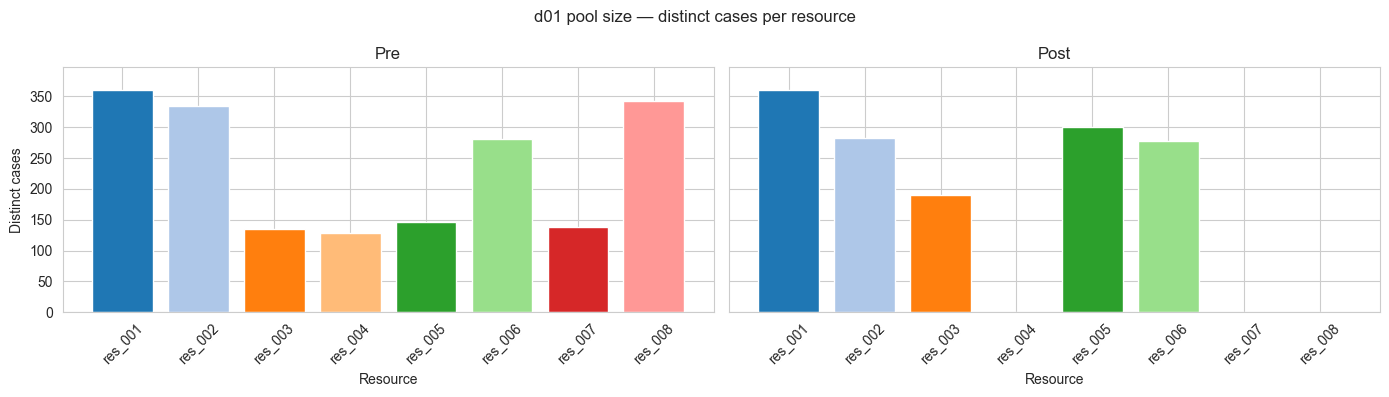

In [92]:
subtype_header(
    "pool_size",
    "Expected signal: distinct active resources, events per resource, and active cases per resource.",
)

weekly_active = df.groupby("week")["resource"].nunique().sort_index()
for drift in drifts_for("pool_size"):
    details = drift.get("change_details") or {}
    print("\n" + drift_title(drift))
    print("old pool size:", details.get("old_pool_size"), "new pool size:", details.get("new_pool_size"))
    print("new active resources:", details.get("active_resources"))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(weekly_active.index, weekly_active.values, marker="o", color="steelblue", linewidth=1.5)
    ax.fill_between(weekly_active.index, weekly_active.values, alpha=0.2, color="steelblue")
    ax.set_title(f"{drift['drift_id']} pool size — distinct active resources per week")
    ax.set_xlabel("Week")
    ax.set_ylabel("Distinct active resources")
    ax.set_ylim(0, weekly_active.max() + 2)
    draw_drift_lines(ax, drifts=[drift], color="red", label_color="red")
    plt.tight_layout()
    plt.show()

    pre, post = pre_post_window(drift)
    plot_resource_bars(
        pre,
        post,
        lambda sub: sub["resource"].value_counts(),
        "Events",
        f"{drift['drift_id']} pool size — events per resource",
    )
    plot_resource_bars(
        pre,
        post,
        lambda sub: sub.groupby("resource")["case_id"].nunique(),
        "Distinct cases",
        f"{drift['drift_id']} pool size — distinct cases per resource",
    )


## 8 · Subtype: `handover`

Visual target: **resource-to-resource transitions inside cases**. This section compares handover
matrices before and after the drift and plots total handovers over time.


handover: 1 drift(s)
Expected signal: resource handover counts, especially source → target transitions.

d05 · sudden · handover @ 2020-05-26 00:00:00+00:00
source: res_005
old target: res_001 new target: res_005


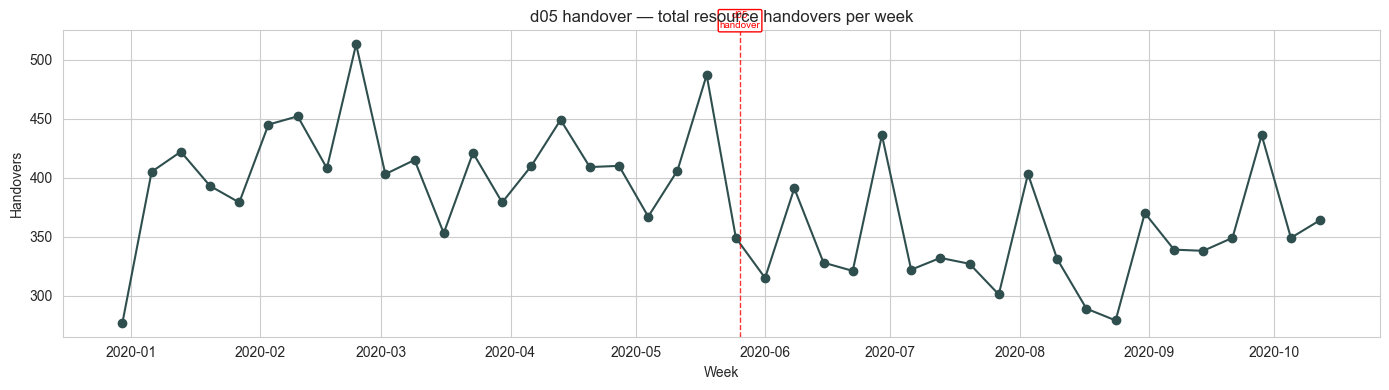

d05 · sudden · handover @ 2020-05-26 00:00:00+00:00
pre:  [2020-04-26 00:00:00+00:00, 2020-05-26 00:00:00+00:00) · 2,526 events · 421 cases · 8 resources
post: [2020-05-26 00:00:00+00:00, 2020-06-25 00:00:00+00:00) · 2,343 events · 392 cases · 5 resources


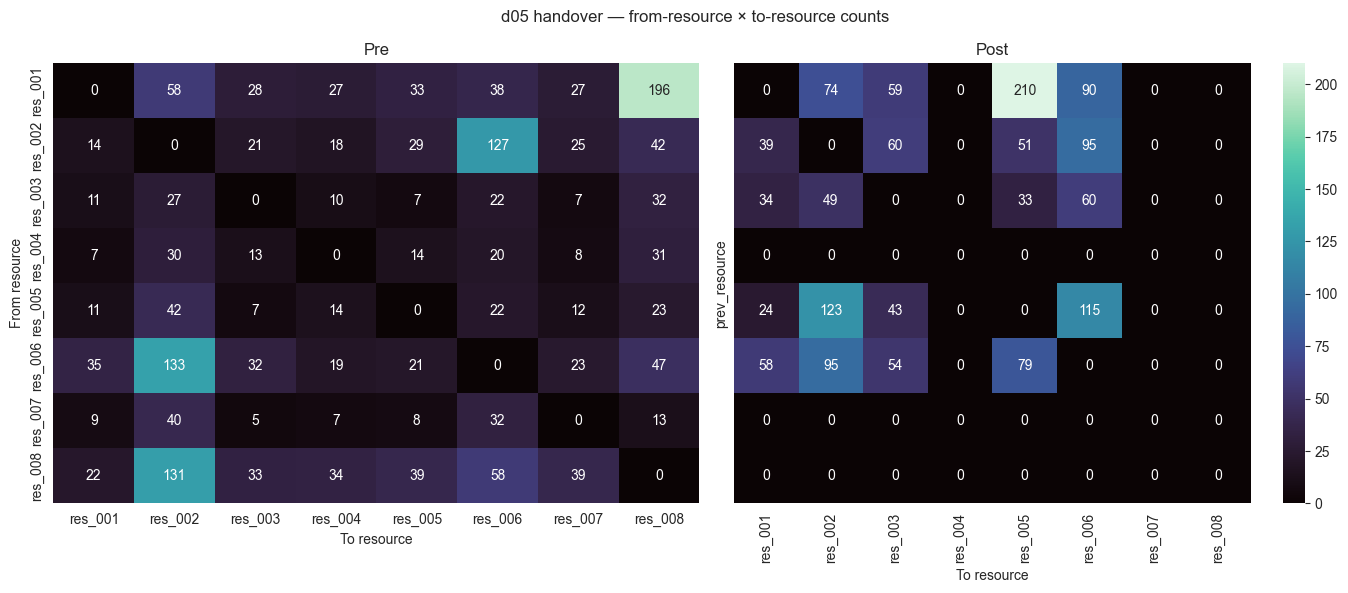

In [93]:
subtype_header(
    "handover",
    "Expected signal: resource handover counts, especially source → target transitions.",
)

weekly_handover_total = handovers.groupby("week").size().sort_index()
for drift in drifts_for("handover"):
    details = drift.get("change_details") or {}
    print("\n" + drift_title(drift))
    print("source:", details.get("source_resource"))
    print("old target:", details.get("old_dominant_target"), "new target:", details.get("new_dominant_target"))

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(weekly_handover_total.index, weekly_handover_total.values, marker="o", color="darkslategray")
    ax.set_title(f"{drift['drift_id']} handover — total resource handovers per week")
    ax.set_xlabel("Week")
    ax.set_ylabel("Handovers")
    draw_drift_lines(ax, drifts=[drift], color="red", label_color="red")
    plt.tight_layout()
    plt.show()

    pre, post = pre_post_window(drift)
    plot_handover_heatmaps(pre, post, f"{drift['drift_id']} handover — from-resource × to-resource counts")


## 9 · Quick subtype-to-feature checklist

Use this as a compact index when deciding which notebook section to inspect.


In [94]:
subtype_feature_map = pd.DataFrame([
    {"subtype": "reassignment", "primary_features": "activity-resource counts, per-activity resource shares"},
    {"subtype": "workload_distribution", "primary_features": "events per resource, active cases per resource"},
    {"subtype": "service_time", "primary_features": "mean event duration, wait time, duration distribution"},
    {"subtype": "pool_size", "primary_features": "distinct active resources, events per resource"},
    {"subtype": "handover", "primary_features": "source → target resource handover counts"},
])
subtype_feature_map["present_in_log"] = subtype_feature_map["subtype"].isin(resource_drift_df["subtype"])
subtype_feature_map


,subtype,primary_features,present_in_log
0,reassignment,"activity-resource counts, per-activity resourc...",True
1,workload_distribution,"events per resource, active cases per resource",True
2,service_time,"mean event duration, wait time, duration distr...",True
3,pool_size,"distinct active resources, events per resource",True
4,handover,source → target resource handover counts,True
